## 1. Вступление. Ответы на вопросы

### i. Напишите 5 примеров применения методов ML в жизни. В чем преимущество использования методов машинного обучения в каждом из ваших примеров?

1. Распознавание голоса в умных колонках - классификация:
Если у колонки несколько владельцев, то это приятная фишка, которая позволяет находить подход к каждому человеку и запоминать паттерны поведения, которые были внесены в настройки
2. Предсказание времени, когда приедет такси - регрессия:
Отсутствие ложного ожидания, оптимизация ресурсов
3. Предсказание кассового сбора фильма - регрессия:
На основании предсказаний можно понять насколько фильм будет востребован и заинтересованность зрителей в данном произведении искусства 
4. Детектор сотрудников в секретной лаборатории - классификация
Необходимо для безопасности
5. Повышение процентной ставки по ипотеке - регрессия
Позволяет управлять рисками, формировать стратегические предложения и прогнозировать прибыль

### ii. Классификация задач из примеров

|Number| Task T | Performance measure P | Experience E | Task type |
|---|---|---|---|---|
|1.|Predict house price|How close to the price we are|Description of every house in a city with fixed characteristics and price|Regression|
|2.|Predict whether a client returns a loan|Is our prediction correct or not. Or the amount of money bank lost if provided a loan but the client has not return it|Salary of clients and their credit history|Classification/regression|
|3.|Predict when a patient needs to take medicine|Whether the medicine helps to recover|Current patient medical record. Performance of randomized control trial with this medicine. Plus the medical records of other patients|Regression|
|4.|Choose what medicine out of available a patient should take|Whether the medicine helps to recover|Current patient medical records. Performance of randomized control trials with these medicines. Plus the medical records of other patients|Classification|
|5.|Choose segment of clients for a promo communication|Open rate of communication Or increase in profit|The information of what items was included in the promo. Clients purchase history. Characteristics of products|Classification/Сlustering/Association|
|6.|Recognition of defective products on the production line (based on photo scans)|The amount of skipped defects|Photos of defective and non-defective products|Classification|
|7.|Decide how to place products on a shelf in a store|The amount of products selled Or increase in profit|	History of how we placed products before. Orders with products’ amounts|Regression|
|8.|Search sites for input text query|The ratio of successful searches. The mean rank of successful answer|Search queries of other users. Text description of every site|Classification/Regression->ranging|
|9.|Split customers of a store into segments to understand differences of their behavior|How well you can interpret splits|Customers’ characteristics and purchase history|Clustering|
|10.|Detect anomaly in site traffic|The amount of prevented DDoS attacks|Stream of requests to your servers|Classification|

### iii.  В чем разница между многоклассовой и многометочной классификацией?

Многоклассовая:

Один объект -> один класс. Всего классов > 2

Многометочная:

Один объект -> может принадлежать нескольким классам. Всего классов >= 2

### iv. Является ли пример с ценами на жилье из теории классификацией регрессионной задачи? Возможно ли свести регрессионную задачу к классификации?

Да, это регрессия.

Можно свести, допустим, будем предсказывать не цену, а сегмент: низкий, средний, премиум

## 2. Введение в анализ данных

In [29]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import PolynomialFeatures
import lightgbm 
import scipy 
import statsmodels 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [30]:
train_df = pd.read_json("rental-price-prediction/data/train.json")
train_df.head(5)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [31]:
print("Размер данных:", len(train_df), "строк,", len(train_df.columns), "столбцов")

Размер данных: 49352 строк, 15 столбцов


In [32]:
print(f"Список столбцов:\n{list(train_df.columns)}")
print(f"Целевой столбец: {train_df["price"].name}")

Список столбцов:
['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']
Целевой столбец: price


In [33]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


Нет пустых значений

In [34]:
train_df.describe()


,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


Количество не пустых значений, среднее арифметическое, стандрартное отклонение, минимальное значение, первый квартиль, медиана, третий квартить, максимальное значение

Возможно где-то ошибка в координатах, т.к. минимальное latitude равно 0 (экватор). Базовая квартира состоит из 1 ванны и 1/2 спален. Сильные разбросы в цене (от 43 до 4490000).

In [35]:
train_df.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


Нет сильно выраженной линеной зависимости, кроме latitude и longitude. Возможно стоит из широты и долготы получить новый признак (удаленность от центра Манхэттена), т.к. большинство квартир находятся рядом с ним.

In [36]:
train_df2 = train_df[['bathrooms', 'bedrooms', 'interest_level', 'price']].copy()

## 3. Анализ статистических данных

### Анализ целевой переменной

<Axes: xlabel='price', ylabel='Count'>

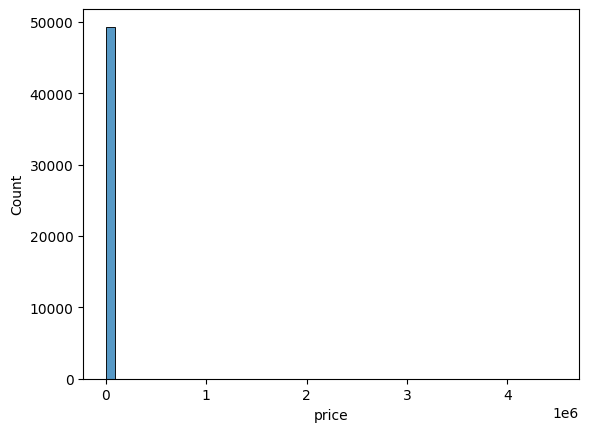

In [37]:
train_df2['log_price'] = np.log1p(train_df2['price'])
sns.histplot(data=train_df2, x='price', bins=50)

<Axes: xlabel='log_price'>

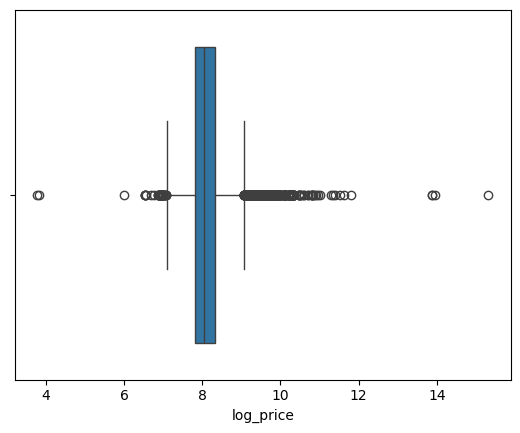

In [38]:
sns.boxplot(data=train_df2, x='log_price')

In [39]:
lower_rows = train_df2['price'].quantile(0.01)
upper_rows = train_df2['price'].quantile(0.99)
train_df2 = train_df2[(train_df2['price'] >= lower_rows) & (train_df2['price'] <= upper_rows)]

<Axes: xlabel='log_price', ylabel='Count'>

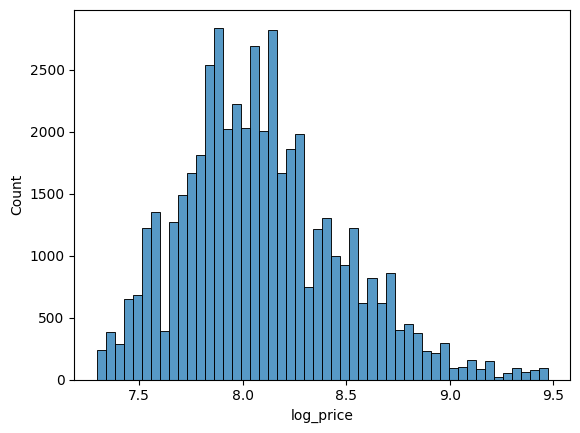

In [40]:
sns.histplot(data=train_df2, x='log_price', bins=50)

Анализ характеристик
Каков тип столбца 'interest_level'?
Выведите значения в этом столбце. Сколько записей содержит каждое значение?
Закодируйте эти значения. Например, вы можете заменить каждое значение на 0, 1 или 2.
Постройте гистограммы для объектов "ванные комнаты", "спальни". Есть ли какие-либо отклонения?

In [41]:
print(f"Тип столбца 'interest_level':{train_df2['interest_level'].dtype}")
print(f"Некоторые значение столбца 'interest_level':\n{train_df2['interest_level'].head(5).to_string(index=False)}")
print(f"Количество записей для каждого значения:\n{train_df2['interest_level'].value_counts()}")

Тип столбца 'interest_level':object
Некоторые значение столбца 'interest_level':
medium
   low
medium
medium
   low
Количество записей для каждого значения:
interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64


In [42]:
train_df2.head(5)

,bathrooms,bedrooms,interest_level,price,log_price
4,1.0,1,medium,2400,7.783641
6,1.0,2,low,3800,8.243019
9,1.0,2,medium,3495,8.159375
10,1.5,3,medium,3000,8.006701
15,1.0,0,low,2795,7.935945


In [43]:
mapping = {'low' : 0, 'medium' : 1, 'high' : 2}
train_df2['interest_level'] = train_df2['interest_level'].map(mapping)
train_df2.head(5)

,bathrooms,bedrooms,interest_level,price,log_price
4,1.0,1,1,2400,7.783641
6,1.0,2,0,3800,8.243019
9,1.0,2,1,3495,8.159375
10,1.5,3,1,3000,8.006701
15,1.0,0,0,2795,7.935945


In [44]:
print(f"Количество записей для каждого значения:\n{train_df2['interest_level'].value_counts()}")

Количество записей для каждого значения:
interest_level
0    33697
1    11116
2     3566
Name: count, dtype: int64


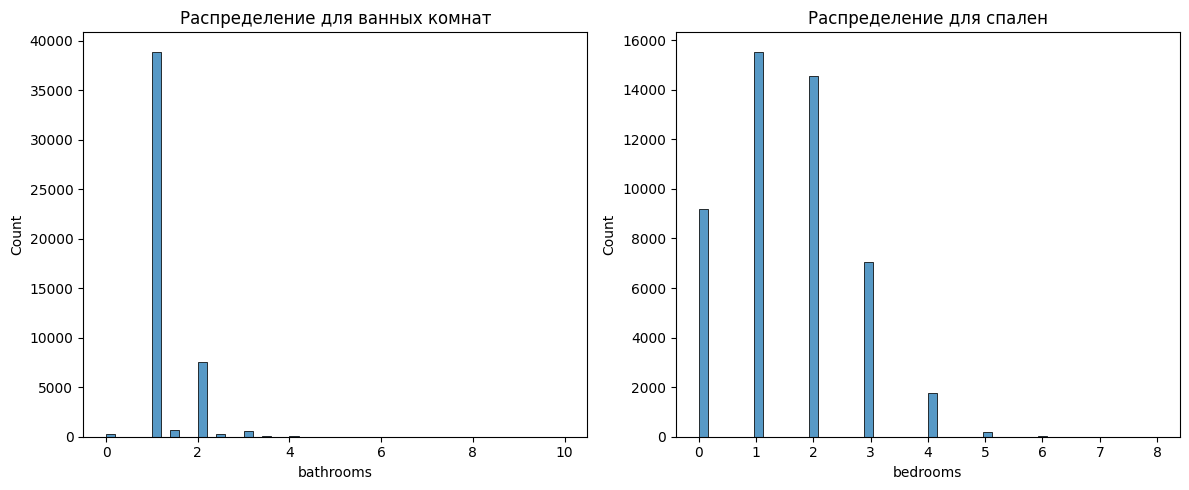

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=train_df2, x='bathrooms', ax=ax1, bins=50)
ax1.set_title("Распределение для ванных комнат")

sns.histplot(data=train_df2, x='bedrooms', ax=ax2, bins=50)
ax2.set_title("Распределение для спален")

plt.tight_layout()
plt.show()

In [46]:
print((train_df2['bathrooms'].value_counts()))

bathrooms
1.0     38928
2.0      7580
1.5       645
3.0       572
0.0       302
2.5       232
4.0        84
3.5        33
10.0        1
5.0         1
4.5         1
Name: count, dtype: int64


Для ванных комнат значения очень разбросаны. В основном преобладают квартиры с 1 ванной комнатой. Возможно объединить выбросы в одну группу: "4+"

In [47]:
print((train_df2['bedrooms'].value_counts()))

bedrooms
1    15540
2    14546
0     9201
3     7061
4     1778
5      206
6       44
8        2
7        1
Name: count, dtype: int64


Тут тоже стоит объединить выбросы в одну группу: "5+"

In [48]:
train_df2.drop(columns='log_price', inplace=True)
train_df2.head(5)

,bathrooms,bedrooms,interest_level,price
4,1.0,1,1,2400
6,1.0,2,0,3800
9,1.0,2,1,3495
10,1.5,3,1,3000
15,1.0,0,0,2795


In [49]:
correlation_matrix = train_df2.corr()
display("Корреляционная матрица:")
display(correlation_matrix.round(3))

'Корреляционная матрица:'

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000,0.518,-0.064,0.672
bedrooms,0.518,1.000,0.051,0.546
interest_level,-0.064,0.051,1.000,-0.200
price,0.672,0.546,-0.200,1.000


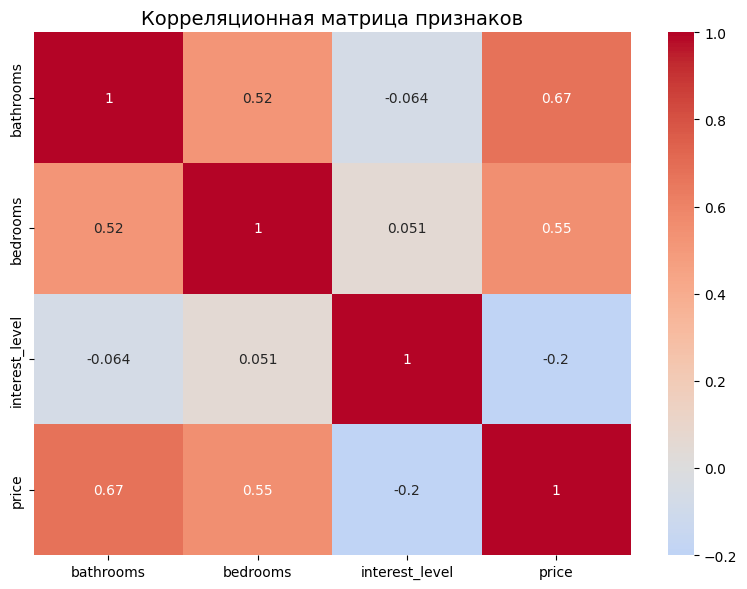

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()

### Диаграммы рассеяния

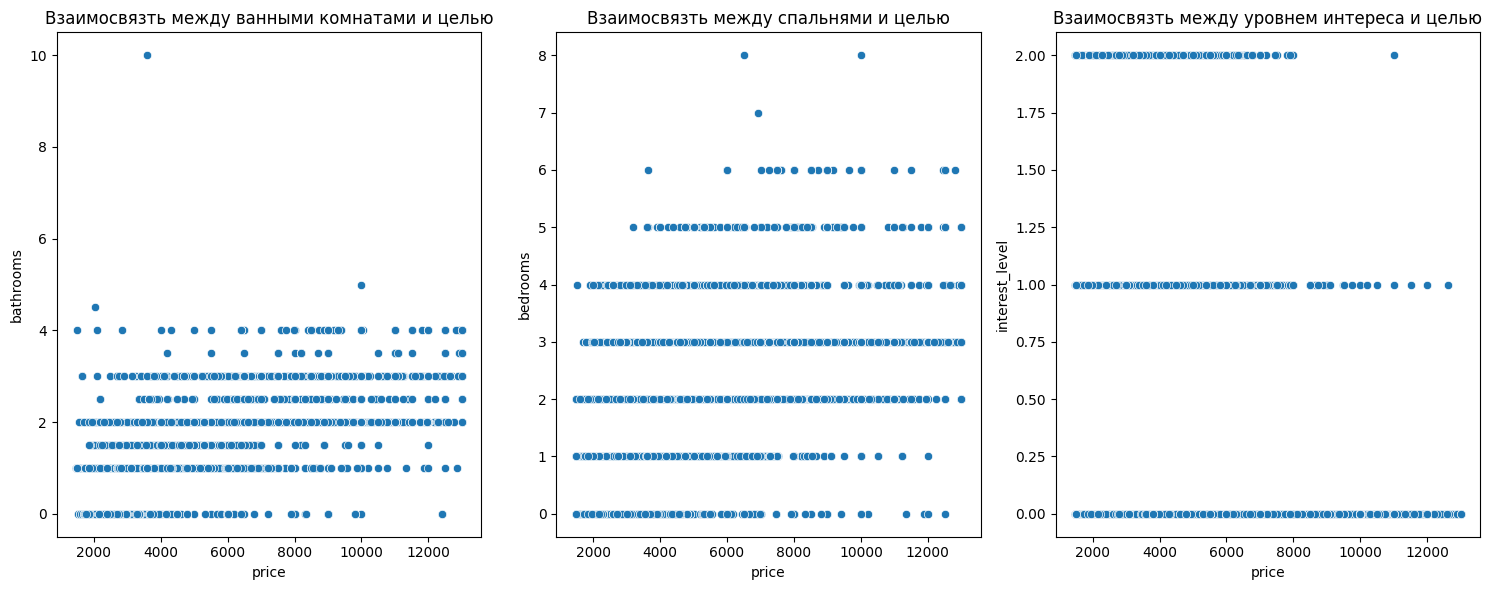

In [51]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))

sns.scatterplot(data=train_df2, x='price', y='bathrooms', ax=ax1)
ax1.set_title("Взаимосвязть между ванными комнатами и целью")

sns.scatterplot(data=train_df2, x='price', y='bedrooms', ax=ax2)
ax2.set_title("Взаимосвязть между спальнями и целью")

sns.scatterplot(data=train_df2, x='price', y='interest_level', ax=ax3)
ax3.set_title("Взаимосвязть между уровнем интереса и целью")

plt.tight_layout()
plt.show()

## Создание новых признаков

In [52]:
train_df2['bathrooms_squared'] = train_df2['bathrooms']**2
train_df2['bedrooms_squared'] = train_df2['bedrooms']**2
train_df2['interest_level_squared'] = train_df2['interest_level']**2
train_df2.head()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.0,1,1,2400,1.00,1,1
6,1.0,2,0,3800,1.00,4,0
9,1.0,2,1,3495,1.00,4,1
10,1.5,3,1,3000,2.25,9,1
15,1.0,0,0,2795,1.00,0,0


In [53]:
correlation_matrix = train_df2.corr()
print("Корреляционная матрица:")
display(correlation_matrix.round(3))

Корреляционная матрица:


,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000,0.518,-0.064,0.672,0.956,0.549,-0.059
bedrooms,0.518,1.000,0.051,0.546,0.479,0.928,0.040
interest_level,-0.064,0.051,1.000,-0.200,-0.069,0.046,0.944
price,0.672,0.546,-0.200,1.000,0.648,0.543,-0.183
bathrooms_squared,0.956,0.479,-0.069,0.648,1.000,0.522,-0.062
bedrooms_squared,0.549,0.928,0.046,0.543,0.522,1.000,0.036
interest_level_squared,-0.059,0.040,0.944,-0.183,-0.062,0.036,1.000


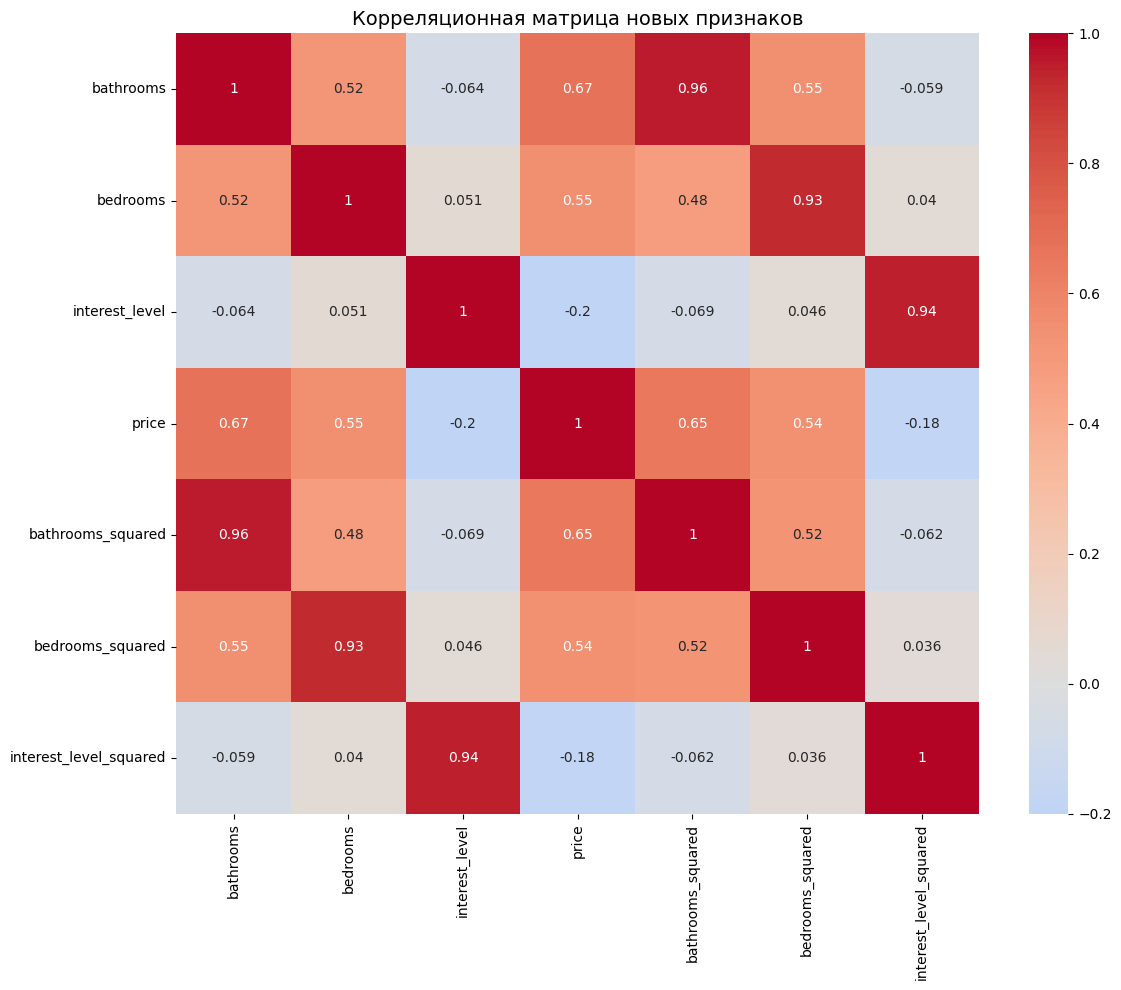

In [54]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица новых признаков', fontsize=14)

plt.tight_layout()
plt.show()

Квадрат ухудшил или не изменил корреляцию с таргетом для ванных комнат и спален. Усилилась обратная зависимоть с уровнем интереса и целевой переменной

In [55]:
train_simple_x = train_df2[['bathrooms', 'bedrooms']]
train_simple_y = train_df2['price']
train_simple_x.head()

,bathrooms,bedrooms
4,1.0,1
6,1.0,2
9,1.0,2
10,1.5,3
15,1.0,0


In [56]:
test = pd.read_json("rental-price-prediction/data/test.json", )
test_simple_x = test[['bathrooms', 'bedrooms']]
test_simple_y = test['price']
test.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"[Elevator, Laundry in Building, Laundry in Uni...",40.7185,7142618,-73.9865,b1b1852c416d78d7765d746cb1b8921f,[https://photos.renthop.com/2/7142618_1c45a2c8...,2950,99 Suffolk Street
1,1.0,2,0,2016-06-24 06:36:34,Prime Soho - between Bleecker and Houston - Ne...,Thompson Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7278,7210040,-74.0000,d0b5648017832b2427eeb9956d966a14,[https://photos.renthop.com/2/7210040_d824cc71...,2850,176 Thompson Street
2,1.0,0,0,2016-06-17 01:23:39,Spacious studio in Prime Location. Cleanbuildi...,Sullivan Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7260,7174566,-74.0026,e6472c7237327dd3903b3d6f6a94515a,[https://photos.renthop.com/2/7174566_ba3a35c5...,2295,115 Sullivan Street
3,1.0,2,f9c826104b91d868e69bd25746448c0c,2016-06-21 05:06:02,For immediate access call Bryan.<br /><br />Bo...,Jones Street,"[Hardwood Floors, Dogs Allowed, Cats Allowed]",40.7321,7191391,-74.0028,41735645e0f8f13993c42894023f8e58,[https://photos.renthop.com/2/7191391_8c2f2d49...,2900,23 Jones Street
5,1.0,1,81062936e12ee5fa6cd2b965698e17d5,2016-06-16 07:24:27,Beautiful TRUE 1 bedroom in a luxury building ...,Exchange Place,"[Roof Deck, Doorman, Elevator, Fitness Center,...",40.7054,7171695,-74.0095,a742cf7dd3b2627d83417bc3a1b3ec96,[https://photos.renthop.com/2/7171695_089ffee2...,3254,20 Exchange Place


In [57]:
poly = PolynomialFeatures(degree = 10)
train_poly = poly.fit_transform(train_simple_x)
test_poly = poly.transform(test_simple_x)

In [58]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [59]:
def result_df(df, name, train, test):
    df = pd.concat([
    df, pd.DataFrame([{
    'model' : name,
    'train' : train,
    'test' : test}])], ignore_index=True)
    return df

## Линейная регрессия

In [60]:
linear_model = LinearRegression()
linear_model.fit(train_simple_x, train_simple_y)

linear_predictions_train = linear_model.predict(train_simple_x)
linear_predictions_test = linear_model.predict(test_simple_x)

linear_mae_train = mean_absolute_error(linear_predictions_train, train_simple_y)
linear_rmse_train = np.sqrt(mean_squared_error(linear_predictions_train, train_simple_y))

linear_mae_test = mean_absolute_error(linear_predictions_test, test_simple_y)
linear_rmse_test = np.sqrt(mean_squared_error(linear_predictions_test, test_simple_y))

result_MAE = result_df(result_MAE, 'linear_regression', linear_mae_train, linear_mae_test)
result_RMSE = result_df(result_RMSE, 'linear_regression', linear_rmse_train, linear_rmse_test)

/var/folders/qf/bz0xqy3n6jnf4wkb0ps2qw100000gn/T/ipykernel_84747/347829541.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([


## Дерево решений

In [61]:
decision_tree = DecisionTreeRegressor(random_state=21)
decision_tree.fit(train_simple_x, train_simple_y)

tree_predictions_train = decision_tree.predict(train_simple_x)
tree_predictions_test = decision_tree.predict(test_simple_x)

tree_mae_train = mean_absolute_error(tree_predictions_train, train_simple_y)
tree_rmse_train = np.sqrt(mean_squared_error(tree_predictions_train, train_simple_y))

tree_mae_test = mean_absolute_error(tree_predictions_test, test_simple_y)
tree_rmse_test = np.sqrt(mean_squared_error(tree_predictions_test, test_simple_y))

result_MAE = result_df(result_MAE, 'decision_tree', tree_mae_train, tree_mae_test)
result_RMSE = result_df(result_RMSE, 'decision_tree', tree_rmse_train, tree_rmse_test)

## Наивная модель

In [62]:
mean_price_train = np.full(len(train_simple_y), np.mean(train_simple_y))
mean_price_test = np.full(len(test_simple_y), np.mean(train_simple_y))

mean_mae_train = mean_absolute_error(mean_price_train, train_simple_y)
mean_rmse_train = np.sqrt(mean_squared_error(mean_price_train, train_simple_y))

mean_mae_test = mean_absolute_error(mean_price_test, test_simple_y)
mean_rmse_test = np.sqrt(mean_squared_error(mean_price_test, test_simple_y))

result_MAE = result_df(result_MAE, 'naive_mean', mean_mae_train, mean_mae_test)
result_RMSE = result_df(result_RMSE, 'naive_mean', mean_rmse_train, mean_rmse_test)

In [63]:
median_price_train = np.full(len(train_simple_y), np.median(train_simple_y))
median_price_test = np.full(len(test_simple_y), np.median(train_simple_y))

median_mae_train = mean_absolute_error(median_price_train, train_simple_y)
median_rmse_train = np.sqrt(mean_squared_error(median_price_train, train_simple_y))

median_mae_test = mean_absolute_error(median_price_test, test_simple_y)
median_rmse_test = np.sqrt(mean_squared_error(median_price_test, test_simple_y))

result_MAE = result_df(result_MAE, 'naive_median', median_mae_train, median_mae_test)
result_RMSE = result_df(result_RMSE, 'naive_median', median_rmse_train, median_rmse_test)

In [64]:
display(result_MAE, result_RMSE)

,model,train,test
0,linear_regression,784.563837,986.046717
1,decision_tree,756.044735,953.592155
2,naive_mean,1139.192515,1374.695973
3,naive_median,1086.210505,1322.640673


,model,train,test
0,linear_regression,1123.877748,9625.054818
1,decision_tree,1077.483596,9589.260857
2,naive_mean,1597.646655,9715.305011
3,naive_median,1644.236439,9731.481148


In [65]:
train_df

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


In [66]:
train_add = train_df[['bathrooms', 'bedrooms', 'latitude', 'longitude', 'interest_level', 'description', 'price']]
train_add

,bathrooms,bedrooms,latitude,longitude,interest_level,description,price
4,1.0,1,40.7108,-73.9539,medium,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,2400
6,1.0,2,40.7513,-73.9722,low,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,3800
9,1.0,2,40.7575,-73.9625,medium,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,3495
10,1.5,3,40.7145,-73.9425,medium,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,3000
15,1.0,0,40.7439,-73.9743,low,Over-sized Studio w abundant closets. Availabl...,2795
...,...,...,...,...,...,...,...
124000,1.0,3,40.8433,-73.9396,low,There is 700 square feet of recently renovated...,2800
124002,1.0,2,40.8198,-73.9578,medium,"2 bedroom apartment with updated kitchen, rece...",2395
124004,1.0,1,40.5765,-73.9554,medium,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,1850
124008,1.0,2,40.7448,-74.0017,medium,Wonderful Bright Chelsea 2 Bedroom apartment o...,4195


In [67]:
train_add = train_add.reset_index(drop=True)
for i in range(len(train_add)):
    if train_add.loc[i, 'bathrooms'] >= 4.0:
        train_add.loc[i, 'bathrooms'] = 4.0

print((train_add['bathrooms'].value_counts()))

bathrooms
1.0    39422
2.0     7660
3.0      745
1.5      645
0.0      313
2.5      277
4.0      220
3.5       70
Name: count, dtype: int64


In [68]:
train_add = train_add.reset_index(drop=True)
for i in range(len(train_add)):
    if train_add.loc[i, 'bedrooms'] >= 5.0:
        train_add.loc[i, 'bedrooms'] = 5.0

print((train_add['bedrooms'].value_counts()))

bedrooms
1    15752
2    14623
0     9475
3     7276
4     1929
5      297
Name: count, dtype: int64


In [69]:
center_lat, center_lon = 40.7580, -73.9855
train_add['distance_to_center'] = np.sqrt(
    (train_add['latitude'] - center_lat)**2 + 
    (train_add['longitude'] - center_lon)**2
)

train_add.drop(columns=['latitude', 'longitude'], inplace=True)

In [70]:
train_add['interest_level'] = train_add['interest_level'].map(mapping)
train_add.head()

,bathrooms,bedrooms,interest_level,description,price,distance_to_center
0,1.0,1,1,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,2400,0.056801
1,1.0,2,0,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,3800,0.014892
2,1.0,2,1,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,3495,0.023005
3,1.5,3,1,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,3000,0.061166
4,1.0,0,0,Over-sized Studio w abundant closets. Availabl...,2795,0.018007


In [71]:
key_words = ['luxury', 'renovated', 'new', 'modern', 'spacious', 'view', 'parking']
sum_words = 0
for word in key_words:
    sum_words += train_add['description'].str.lower().str.contains(word).astype(int)
    train_add['high_prices'] = sum_words

train_add.drop(columns='description', inplace=True)
train_add.head()

,bathrooms,bedrooms,interest_level,price,distance_to_center,high_prices
0,1.0,1,1,2400,0.056801,3
1,1.0,2,0,3800,0.014892,5
2,1.0,2,1,3495,0.023005,2
3,1.5,3,1,3000,0.061166,2
4,1.0,0,0,2795,0.018007,0


In [72]:
correlation_matrix = train_add.corr()
display(correlation_matrix)

,bathrooms,bedrooms,interest_level,price,distance_to_center,high_prices
bathrooms,1.000000,0.535148,-0.082559,0.068254,0.008469,0.077696
bedrooms,0.535148,1.000000,0.027904,0.051671,0.005123,0.073324
interest_level,-0.082559,0.027904,1.000000,-0.023783,-0.005538,0.072228
price,0.068254,0.051671,-0.023783,1.000000,0.000074,-0.002624
distance_to_center,0.008469,0.005123,-0.005538,0.000074,1.000000,-0.002233
high_prices,0.077696,0.073324,0.072228,-0.002624,-0.002233,1.000000
